# Unemployment analysis with Python

CodeAlpha Data Science Internship, Task 2.

Analysis of monthly unemployment rate data for Indian states between May 2019
and June 2020, covering the period immediately before and during the first wave
of Covid-19.

**Objectives**

- Clean and prepare the unemployment rate data
- Explore how rates vary by region and by rural or urban area
- Visualise the trend over the period
- Examine the effect of Covid-19 on unemployment rates
- Draw out any patterns that would be relevant to economic or social policy

**Data source**

`Unemployment in India.csv`, supplied by CodeAlpha. 768 rows before cleaning,
7 columns. Each row is one state, for one month, split by rural or urban area.

**Author**

Ahmed Yunus Albarka

In [6]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Load the data

In [7]:
import pandas as pd
df = pd.read_csv(r"C:\Users\talk2\GitHub\CodeAlpha_UnemploymentAnalysis\Data\Unemployment in India.csv")
print(df.shape)
print(df.dtypes)
df.head()

(768, 7)
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.00,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.00,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.00,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.00,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.00,44.68,Rural


In [8]:
# Show the raw column names exactly as they arrive, wrapped in repr()
# so any leading or trailing spaces are visible rather than invisible
print("Raw column names:")
for c in df.columns:
    print(repr(c))

# Show the data type of each column. Anything that should be numeric
# or a date but shows as object is stored as text
print("\nColumn types:")
print(df.dtypes)

# Show the number of rows and columns as loaded
print("\nShape on load:", df.shape)

# Count missing values per column. Identical counts across several
# columns usually means whole rows are empty rather than scattered gaps
print("\nMissing values per column:")
print(df.isna().sum())

# Count rows where every column is empty.
# axis=1 means look across each row instead of down each column
print("\nCompletely blank rows:", df.isna().all(axis=1).sum())

# Display those blank rows so the problem is visible, not just counted
df[df.isna().all(axis=1)]

Raw column names:
'Region'
' Date'
' Frequency'
' Estimated Unemployment Rate (%)'
' Estimated Employed'
' Estimated Labour Participation Rate (%)'
'Area'

Column types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Shape on load: (768, 7)

Missing values per column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Completely blank rows: 28


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Clean the data

The inspection found three problems:

1. Every column except `Region` and `Area` carries a leading space in its name
2. `Date` is stored as text, so it cannot be sorted or filtered by time
3. A block of completely blank rows sits at the end of the file

Each is fixed below.

In [9]:
# Problem 1: Removing extra-spaces from every column name,
df.columns = df.columns.str.strip()

# Problem 2: convert Date from text into a real date type.
df["Date"] = pd.to_datetime(df["Date"].str.strip(), format="%d-%m-%Y")

# Problem 3: remove the completely blank rows.
df = df.dropna(how="all")

# Removing extra space from the valuve
for col in ["Region", "Frequency", "Area"]:
    df[col] = df[col].str.strip()

# Shorten the three measurement column names so later code stays readable
df = df.rename(columns={
    "Estimated Unemployment Rate (%)": "UnemploymentRate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "ParticipationRate"
})

In [10]:
print("Column names:", list(df.columns))

print("\nDate column type:", df["Date"].dtype)

print("Shape after cleaning:", df.shape)

print("Missing values remaining:", df.isna().sum().sum())

print("\nArea values:", df["Area"].unique())
print("Frequency values:", df["Frequency"].unique())

print("\nPeriod:", df["Date"].min().date(), "to", df["Date"].max().date())

print("Duplicate rows:", df.duplicated().sum())

Column names: ['Region', 'Date', 'Frequency', 'UnemploymentRate', 'Employed', 'ParticipationRate', 'Area']

Date column type: datetime64[ns]
Shape after cleaning: (740, 7)
Missing values remaining: 0

Area values: ['Rural' 'Urban']
Frequency values: ['Monthly']

Period: 2019-05-31 to 2020-06-30
Duplicate rows: 0


## 4. Explore the data

The cleaned table holds 740 rows covering 14 months, with each row giving one
region, for one month, split by rural or urban area.

In [17]:
# Frequency holds the same value in every row, so it carries no information.
df = df.drop(columns=["Frequency"], errors="ignore")

# Summary statistics for the numeric columns: count, mean, spread,
# minimum, quartiles and maximum
df.describe()

,Date,UnemploymentRate,Employed,ParticipationRate
count,740,740.00,740.00,740.00
mean,2019-12-12 18:36:58.378378496,11.79,7204460.03,42.63
min,2019-05-31 00:00:00,0.00,49420.00,13.33
25%,2019-08-31 00:00:00,4.66,1190404.50,38.06
50%,2019-11-30 00:00:00,8.35,4744178.50,41.16
75%,2020-03-31 00:00:00,15.89,11275489.50,45.51
max,2020-06-30 00:00:00,76.74,45777509.00,72.57
std,NaN,10.72,8087988.43,8.11


## 5. Visualise the trend

Three views: the overall trend across the period, the same trend split by rural
and urban area, and a comparison across regions.

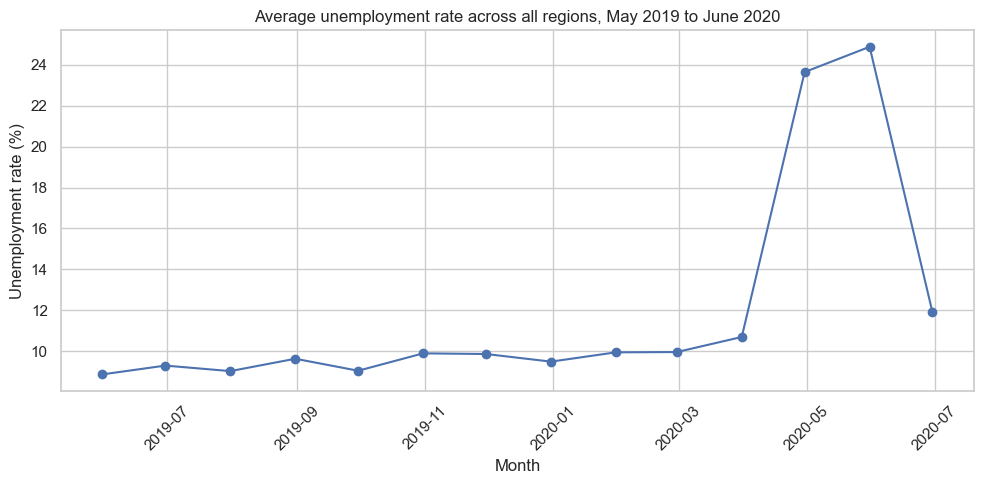

In [19]:
# Average the unemployment rate across all regions for each month,
# giving one national figure per month
monthly = df.groupby("Date")["UnemploymentRate"].mean().reset_index()

# Draw the monthly figure as a line so the direction of travel is visible
plt.plot(monthly["Date"], monthly["UnemploymentRate"], marker="o")

# Label the chart so it can be read without the surrounding code
plt.title("Average unemployment rate across all regions, May 2019 to June 2020")
plt.xlabel("Month")
plt.ylabel("Unemployment rate (%)")

# Rotate the date labels so they do not overlap each other
plt.xticks(rotation=45)

# Tighten the spacing so the rotated labels are not cut off
plt.tight_layout()
plt.show()

The national average holds in a narrow band between roughly 9% and 10% from
May 2019 through February 2020, with March 2020 only slightly higher at about
10.7%. From April the series breaks away completely, reaching around 23.6% and
peaking near 24.9% in May, roughly two and a half times the pre-March average.
June falls back sharply to about 11.9%, close to the earlier band but still
above it. The rise and the fall both happen within three months, which points
to a sudden shock rather than a gradual deterioration in the labour market.

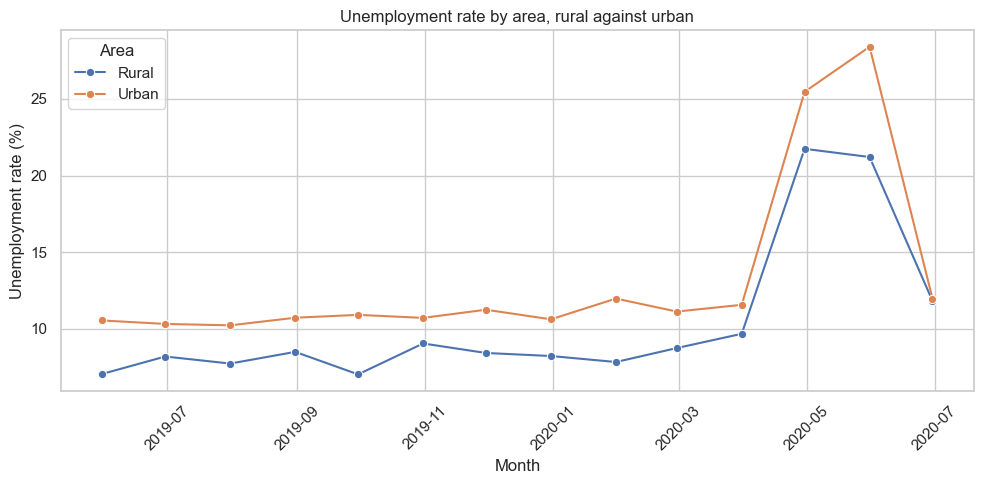

In [22]:
# Average the rate for each month, kept separate for rural and urban
by_area = df.groupby(["Date", "Area"])["UnemploymentRate"].mean().reset_index()

# Plot one line per area, so the two can be compared directly.
# hue tells seaborn to split the data by the Area column
sns.lineplot(data=by_area, x="Date", y="UnemploymentRate", hue="Area", marker="o")

plt.title("Unemployment rate by area, rural against urban")
plt.xlabel("Month")
plt.ylabel("Unemployment rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Urban unemployment runs consistently above rural across the pre-2020 months,
sitting between roughly 10% and 12% against 7% to 9% for rural, a gap of about
two to three percentage points. Both series break upward in April 2020, but not
by the same amount. Urban climbs to around 25.4% and peaks near 28% in May,
while rural reaches about 21.7% in April and holds near 21.2% in May. The gap
between them therefore widened at the peak, from roughly two points before the
shock to close to seven points in May, so the disruption fell harder on urban
labour markets.

The two lines converge at around 11.9% in June, closing the gap almost entirely.
This is the one point in the whole period where rural and urban unemployment sit
level, and it comes from urban falling much further than rural rather than from
rural rising.

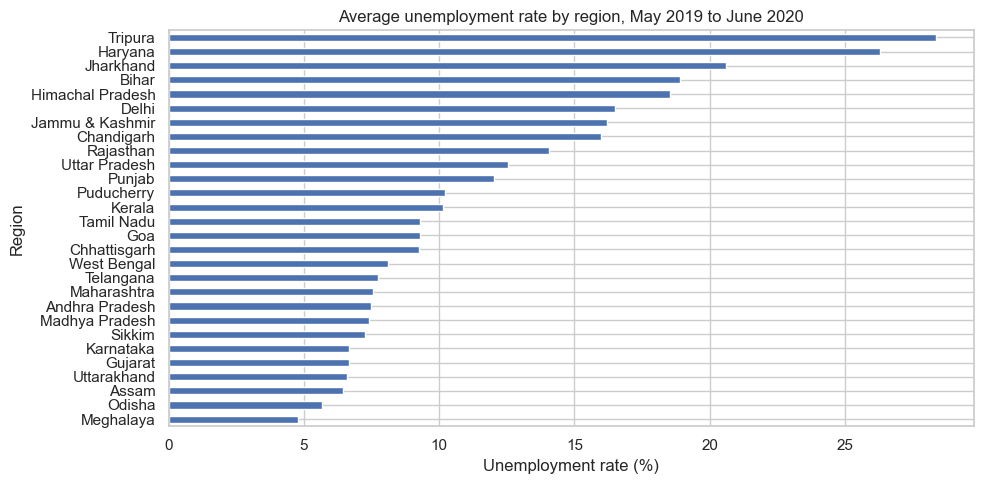

In [21]:
# Average the rate for each region across the whole period,
# then sort so the worst affected appear first
by_region = df.groupby("Region")["UnemploymentRate"].mean().sort_values(ascending=False)

# Draw a horizontal bar chart. Horizontal keeps the region names readable
# where a vertical chart would squash them together
by_region.plot(kind="barh")

plt.title("Average unemployment rate by region, May 2019 to June 2020")
plt.xlabel("Unemployment rate (%)")
plt.ylabel("Region")

# Reverse the vertical axis so the highest value sits at the top
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Average unemployment over the period varies enormously across regions. Tripura
is highest at roughly 28.4%, followed by Haryana near 26.3%, Jharkhand about
20.5% and Bihar about 19%. At the other end, Meghalaya sits near 4.8% and Odisha
about 5.7%, with Assam, Uttarakhand, Gujarat and Karnataka clustered around
6.5%. The highest regional average is close to six times the lowest, a far wider
spread than anything visible in the national series.

Delhi and Chandigarh both sit in the upper group, at roughly 18.5% and 15.9%.
Both are predominantly urban territories, which is consistent with the rural and
urban split seen above.

This chart averages across all fourteen months, so it mixes the pre-lockdown and
lockdown periods together. A high average here could mean a persistently weak
labour market, or a normal one that suffered a severe short shock. The two are
not separable from this view, and section 6 splits them apart.

In [26]:
print(by_region.round(1))

Region
Tripura            28.40
Haryana            26.30
Jharkhand          20.60
Bihar              18.90
Himachal Pradesh   18.50
Delhi              16.50
Jammu & Kashmir    16.20
Chandigarh         16.00
Rajasthan          14.10
Uttar Pradesh      12.60
Punjab             12.00
Puducherry         10.20
Kerala             10.10
Tamil Nadu          9.30
Goa                 9.30
Chhattisgarh        9.20
West Bengal         8.10
Telangana           7.70
Maharashtra         7.60
Andhra Pradesh      7.50
Madhya Pradesh      7.40
Sikkim              7.20
Karnataka           6.70
Gujarat             6.70
Uttarakhand         6.60
Assam               6.40
Odisha              5.70
Meghalaya           4.80
Name: UnemploymentRate, dtype: float64


## 6. The effect of Covid-19

India entered national lockdown on 25 March 2020. The data is split at that
point to compare the months before against the months from April 2020 onward.

In [29]:
# Define the lockdown start date as a proper timestamp so it can be compared against the Date column
lockdown_start = pd.Timestamp("2020-03-25")

# Create a label for each row saying whether it falls before or after
df["Period"] = np.where(df["Date"] < lockdown_start, "Before lockdown", "During lockdown")

# Compare the average unemployment rate across the two periods
print("Mean unemployment rate by period:")
print(df.groupby("Period")["UnemploymentRate"].mean())

# Compare the same split within rural and urban separately,
# since the two may have been affected differently
print("\nMean unemployment rate by period and area:")
print(df.groupby(["Period", "Area"])["UnemploymentRate"].mean())

Mean unemployment rate by period:
Period
Before lockdown    9.51
During lockdown   17.77
Name: UnemploymentRate, dtype: float64

Mean unemployment rate by period and area:
Period           Area 
Before lockdown  Rural    8.09
                 Urban   10.84
During lockdown  Rural   16.18
                 Urban   19.28
Name: UnemploymentRate, dtype: float64


The national average rose from 9.51% before lockdown to 17.77% during it, an
increase of 8.26 percentage points, or close to double.

Split by area, rural rose from 8.09% to 16.18% and urban from 10.84% to 19.28%.
In percentage-point terms the two moved almost identically, 8.09 against 8.44.
In proportional terms rural doubled exactly while urban rose by around 78%, so
the relative shock was slightly heavier on rural labour markets even though the
absolute increase was marginally larger in urban ones.

The gap between rural and urban is 2.75 points before lockdown and 3.10 points
during it, which suggests the two widened only slightly. That average is
misleading. The monthly view in section 5 shows the gap opening to close to
seven points at the May peak, then closing almost entirely in June. Pooling four
months into one figure flattens both movements out. The period average is a fair
summary of the whole episode and a poor description of its worst point.

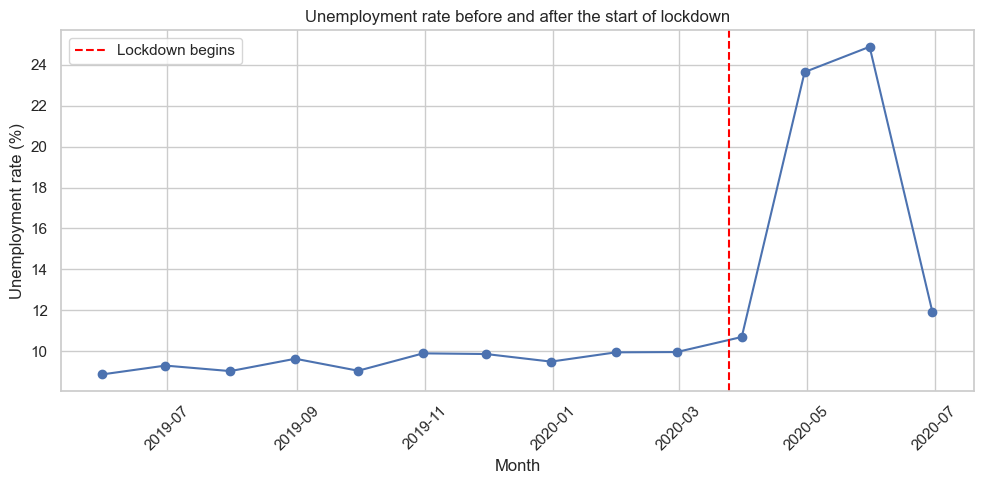

In [30]:
# Reuse the monthly national average calculated in section 5
monthly = df.groupby("Date")["UnemploymentRate"].mean().reset_index()

# Plot the trend again, this time marking the lockdown date on the chart
plt.plot(monthly["Date"], monthly["UnemploymentRate"], marker="o")

# Draw a vertical line at the lockdown date. linestyle and color make it clearly a reference line rather than part of the data
plt.axvline(lockdown_start, color="red", linestyle="--", label="Lockdown begins")

plt.title("Unemployment rate before and after the start of lockdown")
plt.xlabel("Month")
plt.ylabel("Unemployment rate (%)")

# Show the legend so the red line is explained on the chart itself
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The reference line marks 25 March 2020, when national lockdown began. March
itself sits at about 10.7%, barely above the preceding months, because only the
final week of that month fell under restrictions. The effect appears in April,
the first full month of lockdown, at around 23.6%.

The recovery is almost as fast as the rise. June falls back to roughly 11.9%,
within reach of the pre-lockdown band, after only two months at elevated levels.
This is the shape of a labour market interrupted rather than one in structural
decline, though fourteen months of data cannot show whether that recovery held.

In [31]:
# Average the rate per region for each period, then reshape so the two uiperiods sit side by side as columns rather than stacked as rows
change = df.groupby(["Region", "Period"])["UnemploymentRate"].mean().unstack()

# Calculate the change in percentage points for each region
change["Change"] = change["During lockdown"] - change["Before lockdown"]

# Sort so the regions with the largest increase appear first
change = change.sort_values("Change", ascending=False)

# Show the ten regions where unemployment rose most
print("Largest increases in unemployment rate, percentage points:")
print(change.head(10))

Largest increases in unemployment rate, percentage points:
Period          Before lockdown  During lockdown  Change
Region                                                  
Puducherry                 1.59            38.96   37.36
Tamil Nadu                 2.84            25.40   22.57
Jharkhand                 14.28            36.35   22.07
Bihar                     13.83            31.63   17.80
Karnataka                  3.23            15.28   12.05
Haryana                   22.94            34.65   11.72
Kerala                     6.99            17.95   10.96
Telangana                  4.66            15.44   10.79
Madhya Pradesh             4.74            14.07    9.33
Andhra Pradesh             5.04            13.58    8.54


The regional breakdown shows a far larger effect than the national average
suggests. Puducherry rose from 1.59% before lockdown to 38.96% during it, a
change of 37.36 percentage points from an almost negligible starting base. Tamil
Nadu followed a similar path, 2.84% to 25.40%, as did Karnataka and Telangana.

A second group behaves differently. Jharkhand, Bihar and Haryana all carried
double-digit unemployment before lockdown, at 14.28%, 13.83% and 22.94%
respectively, and rose further to 36.35%, 31.63% and 34.65%. These are not
regions knocked off a healthy baseline, they are regions with existing weakness
that deteriorated.

Ranking by percentage-point change places both groups on the same list, but they
describe different problems. A region moving from 1.59% to 38.96% has suffered a
sudden shock to a functioning labour market. A region moving from 22.94% to
34.65% had a labour market already under strain.

One caveat on the period split. Because the dates are recorded at month end,
March 2020 falls into the during-lockdown group despite only its final week
being affected, and June is included after the rate had largely recovered. The
during-lockdown average therefore sits below the April and May peak and should
be read as a period average rather than a measure of the worst point.

## 7. Patterns and policy insights

In [36]:
# For each calendar month, count how many different years it appears in.
# Measuring a seasonal pattern requires the same month observed across7 several years, so that a recurring rise can be separated from a one-off
month_coverage = df.groupby(df["Date"].dt.month_name())["Date"].apply(lambda s: s.dt.year.nunique())

# Sort by the count so any month appearing more than once stands out
print("Number of years each calendar month appears in:")
print(month_coverage.sort_values(ascending=False))

Number of years each calendar month appears in:
Date
June         2
May          2
April        1
August       1
December     1
February     1
January      1
July         1
March        1
November     1
October      1
September    1
Name: Date, dtype: int64


### On seasonality

The task asks for seasonal trends, but this data cannot support a claim about
them. Measuring seasonality requires the same calendar month observed across
several years, so that a recurring rise can be separated from a one-off event.

The series runs from May 2019 to June 2020, fourteen months. Only May and June
appear twice. Every other calendar month appears once, and both 2020 occurrences
of May and June fall inside the lockdown period, when the rate was at its most
disturbed. There is no month in this data where a normal year can be compared
against another normal year.

No seasonal pattern is claimed here. The month-to-month movement between May
2019 and February 2020 stays within roughly one percentage point, which is
consistent with a stable series rather than a seasonal cycle, but a single year
cannot distinguish the two. Establishing seasonality would need at least three
years of the same monthly series.

In [37]:
# Average the labour participation rate for each month across all regions
participation = df.groupby("Date")["ParticipationRate"].mean().reset_index()

# Print it to one decimal place alongside the period it covers
print("Monthly labour participation rate:")
print(participation.set_index("Date")["ParticipationRate"].round(1))

# Compare the participation rate before and during lockdown,
# using the same period split created in section 6
print("\nMean participation rate by period:")
print(df.groupby("Period")["ParticipationRate"].mean().round(2))

Monthly labour participation rate:
Date
2019-05-31   43.90
2019-06-30   43.80
2019-07-31   43.70
2019-08-31   43.60
2019-09-30   44.30
2019-10-31   44.00
2019-11-30   44.10
2019-12-31   43.70
2020-01-31   44.10
2020-02-29   43.70
2020-03-31   43.10
2020-04-30   35.10
2020-05-31   38.50
2020-06-30   40.50
Name: ParticipationRate, dtype: float64

Mean participation rate by period:
Period
Before lockdown   43.89
During lockdown   39.33
Name: ParticipationRate, dtype: float64


Labour participation moves opposite to unemployment across the whole period. It
holds between 43.60% and 44.30% from May 2019 through February 2020, slips to
43.10% in March, then falls to 35.10% in April. That is a drop of 8.00
percentage points in a single month, the same month unemployment jumped to
23.6%. Recovery is partial: 38.50% in May and 40.50% in June, still 3.4 points
below the pre-lockdown average of 43.89%.

Unemployment counts only those without work who are actively seeking it. People
who stop searching leave the labour force and drop out of the unemployment rate
rather than adding to it. Participation falling 8 points in the same month
unemployment more than doubled means a substantial number left the labour force
altogether, so the 24.9% peak understates the disruption rather than
exaggerating it.

The two measures also recover at different speeds. Unemployment returns to
11.9% by June, close to its earlier band. Participation reaches only 40.50%,
still short of every single pre-lockdown month in the series. Some of those who
left the labour force had not returned by the end of the data.

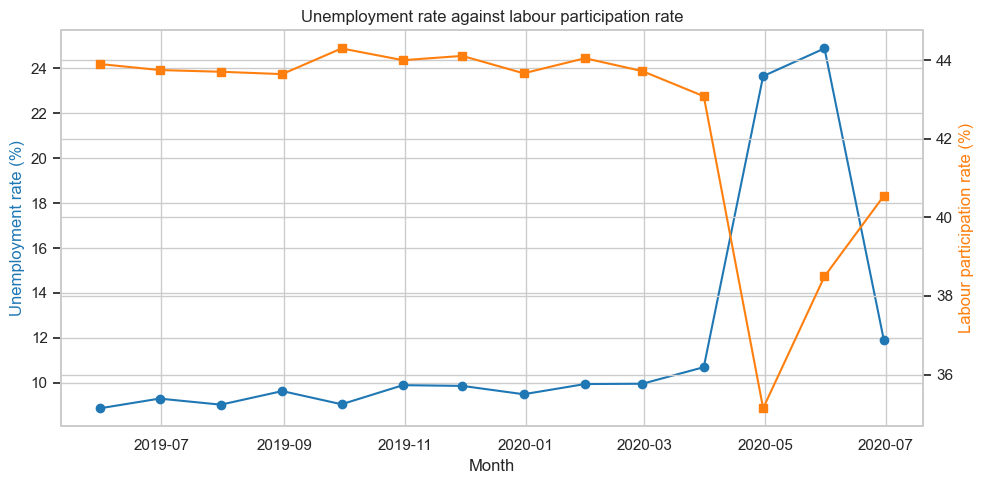

In [38]:
# Plot the unemployment rate and the participation rate on the same time axis so the direction of each can be compared month by month
fig, ax1 = plt.subplots()

# Left axis carries the unemployment rate
ax1.plot(monthly["Date"], monthly["UnemploymentRate"], marker="o", color="tab:blue", label="Unemployment rate")
ax1.set_ylabel("Unemployment rate (%)", color="tab:blue")
ax1.set_xlabel("Month")

# twinx creates a second y-axis sharing the same x-axis,
# because the two measures sit on different scales
ax2 = ax1.twinx()
ax2.plot(participation["Date"], participation["ParticipationRate"], marker="s", color="tab:orange", label="Participation rate")
ax2.set_ylabel("Labour participation rate (%)", color="tab:orange")

plt.title("Unemployment rate against labour participation rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Labour participation moves opposite to unemployment across the whole period. It
holds between roughly 43% and 44.5% through February 2020, slips to about 42.7%
in March, then falls to around 35% at its trough, recovering to about 40.5% by
June without returning to its earlier level.

Unemployment counts only those without work who are actively seeking it. People
who stop searching leave the labour force and drop out of the unemployment rate
rather than adding to it. Participation falling by eight to nine points while
unemployment doubled means a substantial number left the labour force
altogether, so the 24.9% peak understates the disruption rather than
exaggerating it.

Participation also recovers more slowly than unemployment. Unemployment returns
close to its earlier band by June while participation remains several points
below where it started, which suggests some of those who left had not returned
by the end of the data.

### Insights relevant to policy

The disruption was severe and brief. The national rate went from 9.51% before
lockdown to a peak near 24.9% in May, then back to 11.9% by June. The whole
episode ran three months. Any support instrument assessed quarterly would have
been designed after the peak had passed.

Regions divide into two groups that call for different responses. Puducherry
(1.59% to 38.96%), Tamil Nadu (2.84% to 25.40%), Karnataka (3.23% to 15.28%) and
Telangana (4.66% to 15.44%) were functioning labour markets hit by an external
shock, where temporary income support addresses the problem. Jharkhand (14.28%
to 36.35%), Bihar (13.83% to 31.63%) and Haryana (22.94% to 34.65%) already
carried double-digit unemployment before March 2020 and worsened from there.
Short-term relief does not resolve that.

Urban labour markets took the sharper hit at the peak. The rural and urban gap
widened from roughly two points before the shock to close to seven points in
May, before closing almost entirely in June. In proportional terms rural fared
worse over the period as a whole, doubling from 8.09% to 16.18% against urban's
78% rise.

Unemployment on its own would have understated the damage. Participation fell
8.00 points in April, so people were leaving the labour force rather than being
counted as unemployed. Monitoring that used the unemployment rate alone would
have registered a smaller event than the one that occurred.

### Limitations

Fourteen months is too short to establish trend or seasonality, as set out above.
The data ends in June 2020, so whether the recovery held is unknown. Regional
averages are unweighted, meaning each state counts equally regardless of
population, so the national figures here are averages of regions rather than
national totals.